# <center>**IROS**<center>

**Libraries**

In [1]:
#from pathlib import Path
import numpy as np
import mbloodmoon.iros_management as iros
import mbloodmoon as bm

from IROS_pipeline import _handle_dirpaths

In [2]:
mask_FITS = "wfm_mask.fits"

#skyfield = "GalacticCenter"
skyfield = "Crab"
#data_FITS = "20241011_galctr_rxte_sax_2-30keV_1ks_2cams_sources_cxb"
#data_FITS = "20250320_galctr_rxte_sax_2-50keV_1ks_sources_cxb_infmaskdet"
#data_FITS = "20250131_galctr_rxte_sax_2-30keV_1ks_sources_cxb"
#data_FITS = "20250430_galctr_rxte_sax_2-50keV_1ks_realmask_infdet_sources_cxb"
#data_FITS = "20250430_galctr_rxte_sax_2-50keV_1ks_opaquemask_realdet_sources_cxb"
#data_FITS = "20250430_galctr_rxte_sax_2-50keV_1ks_thinmask_realdet_sources_cxb"

data_FITS = "20250227_crab_cxb_2-50keV_1ks"


N_TEST = "crab_offset"

mask_path, simul_data, save_path = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
    test_name=N_TEST,
)

cam_a = "cam1a"
cam_b = "cam1b"
dataset = "detected"

filepaths = bm.simulation_files(simul_data)
#sdlA = bm.simulation(filepaths[cam_a][dataset])
#sdlB = bm.simulation(filepaths[cam_b][dataset])

catalogA = bm.simulation(filepaths[cam_a]["sources"])
catalogB = bm.simulation(filepaths[cam_b]["sources"])

In [3]:
mask_path, simul_data, save_path

('/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations/wfm_mask.fits',
 '/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations/Crab/20250227_crab_cxb_2-50keV_1ks/',
 '/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Outputs/OutCrab/20250227_crab_cxb_2-50keV_1ks/crab_offset/')

In [4]:
database_name = save_path + f"IROS_sources_database_TEST_{N_TEST}.fits"
database = iros.load_iros_data(database_name)

# Loading data...
# Loading completed!


- Scatter plot with RA and DEC residues

In [5]:
print(
    f"# CAM A database: {database[cam_a]["catalog_name"]["data"]}\n",
    f"# CAM B database: {database[cam_b]["catalog_name"]["data"]}\n",
    f"# Same sources: {np.all(database[cam_a]["catalog_name"]["data"] == database[cam_b]["catalog_name"]["data"])}"
)

# TODO: automate source selection in database

# CAM A database: ['crab']
 # CAM B database: ['crab']
 # Same sources: True


# Checking CAM1A...
# Checking CAM1B...


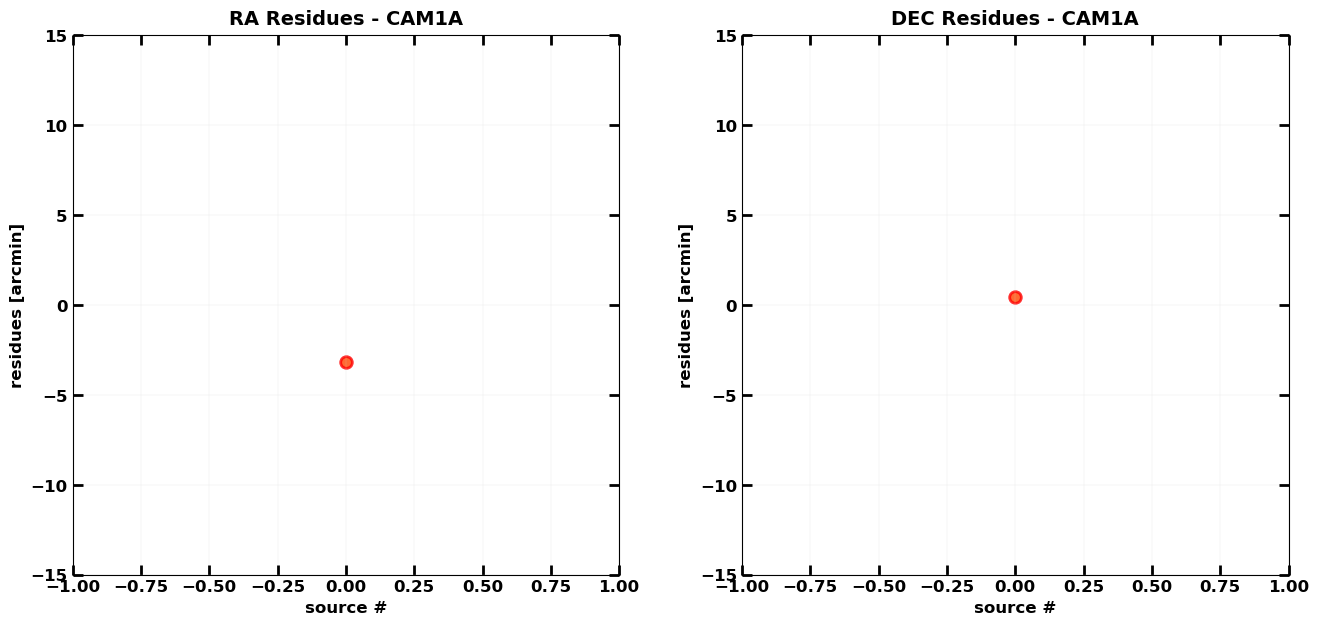

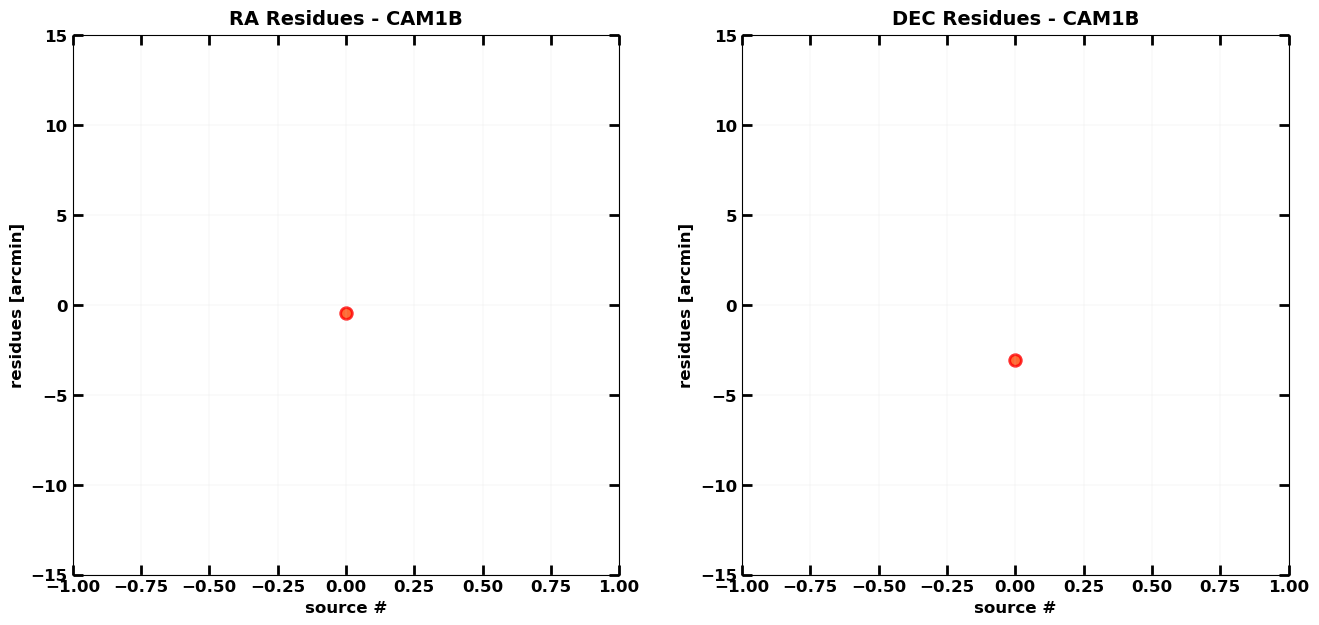

In [6]:
res_df = iros.iros_sources_res(database, (catalogA, catalogB))
#res_df = res_df.drop(index=13)

for cameraID in (cam_a, cam_b):
    iros.plot_sequence(
        input_sequence=[60 * res_df[cameraID]["ra_res"], 60 * res_df[cameraID]["dec_res"]],
        title=[e + f" Residues - {cameraID.upper()}" for e in ["RA", "DEC"]],
        xlabel=[r"source #"]*2,
        ylabel=["residues [arcmin]"]*2,
        style=["scatter"]*2,
        offsetx=[(-1, len(res_df[cameraID]["ra_res"]))]*2,
        offsety=[(-15, 15)]*2,
    )

- Scatter plot with RA/DEC residues vs off-axis angles $\theta_{y}$, $\theta_{x}$

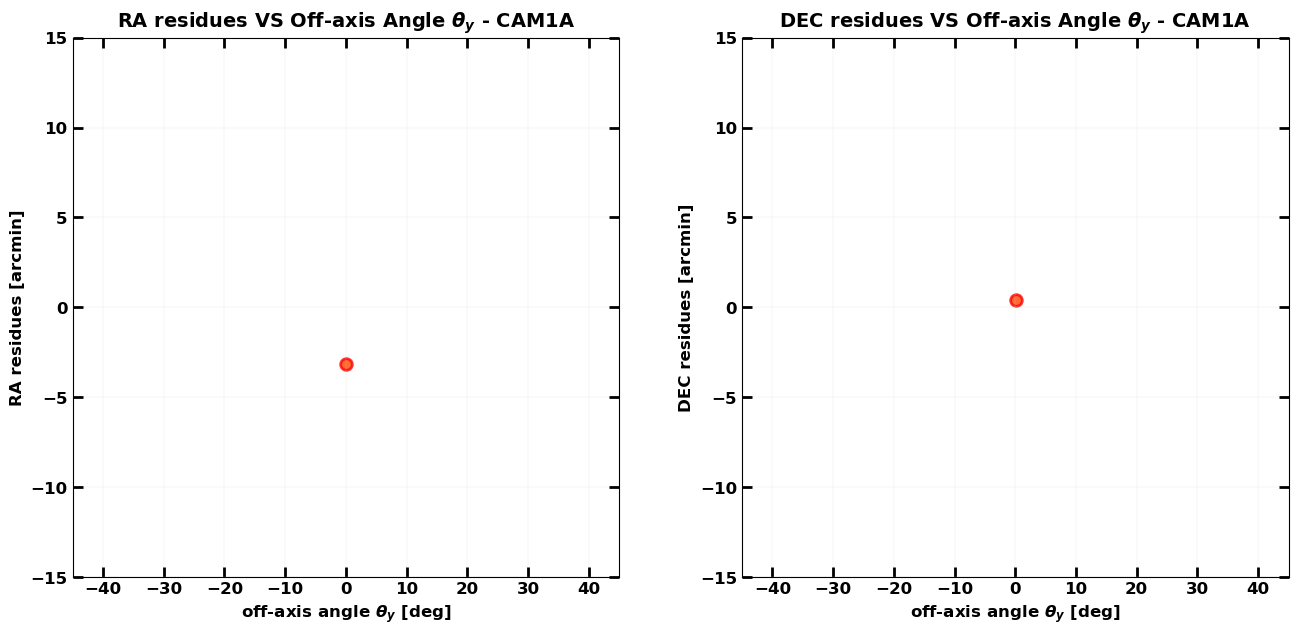

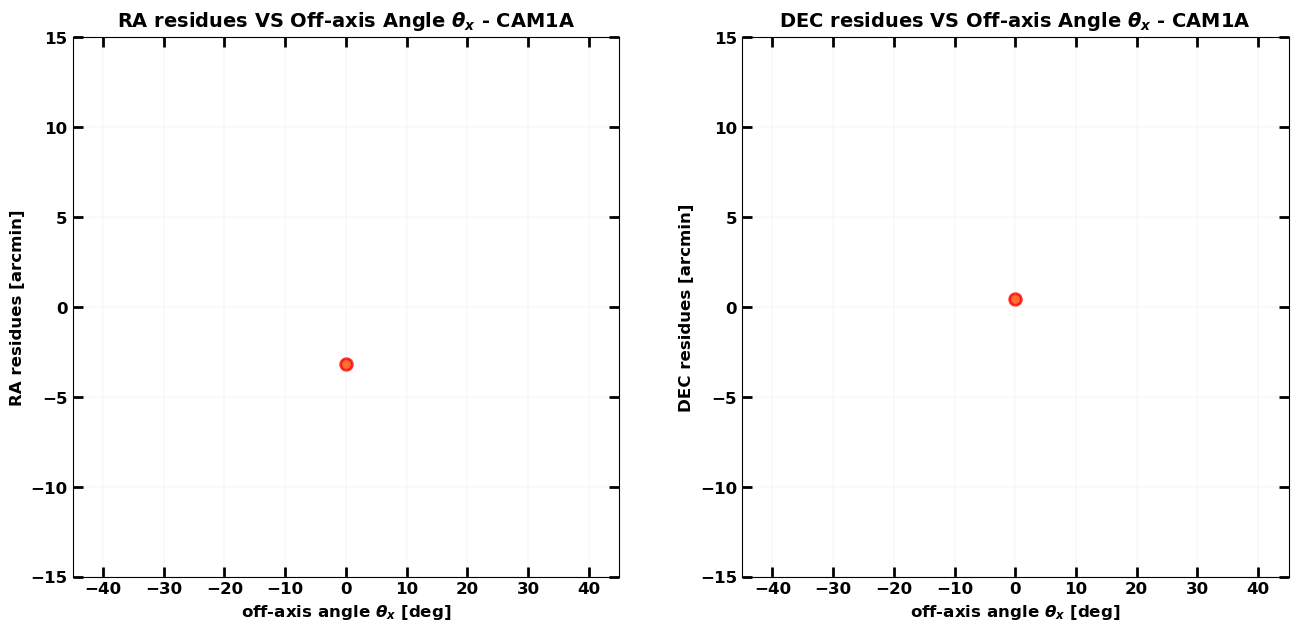

In [7]:
# CAM 1A
ra_res_cam1a = 60 * res_df[cam_a]["ra_res"]
thetay_cam1a = database[cam_a]["theta_y"]["data"]

dec_res_cam1a = 60 * res_df[cam_a]["dec_res"]
thetax_cam1a = database[cam_a]["theta_x"]["data"]

#thetay_cam1a = np.delete(thetay_cam1a, 13); thetax_cam1a = np.delete(thetax_cam1a, 13)


offsetx = [(-45, 45)] * 2
offsety = [(-15, 15)] * 2

iros.plot_sequence(
    input_sequence=[ra_res_cam1a, dec_res_cam1a],
    title=[r"RA residues VS Off-axis Angle $\theta_{y}$ - CAM1A", r"DEC residues VS Off-axis Angle $\theta_{y}$ - CAM1A"],
    x=[thetay_cam1a, thetay_cam1a],
    xlabel=[r"off-axis angle $\theta_{y}$" + " [deg]", r"off-axis angle $\theta_{y}$" + " [deg]"],
    ylabel=["RA residues [arcmin]", "DEC residues [arcmin]"],
    style=["scatter"]*2,
    offsetx=offsetx,
    offsety=offsety,
)
iros.plot_sequence(
    input_sequence=[ra_res_cam1a, dec_res_cam1a],
    title=[r"RA residues VS Off-axis Angle $\theta_{x}$ - CAM1A", r"DEC residues VS Off-axis Angle $\theta_{x}$ - CAM1A"],
    x=[thetax_cam1a, thetax_cam1a],
    xlabel=[r"off-axis angle $\theta_{x}$" + " [deg]", r"off-axis angle $\theta_{x}$" + " [deg]"],
    ylabel=["RA residues [arcmin]", "DEC residues [arcmin]"],
    style=["scatter"]*2,
    offsetx=offsetx,
    offsety=offsety,
)

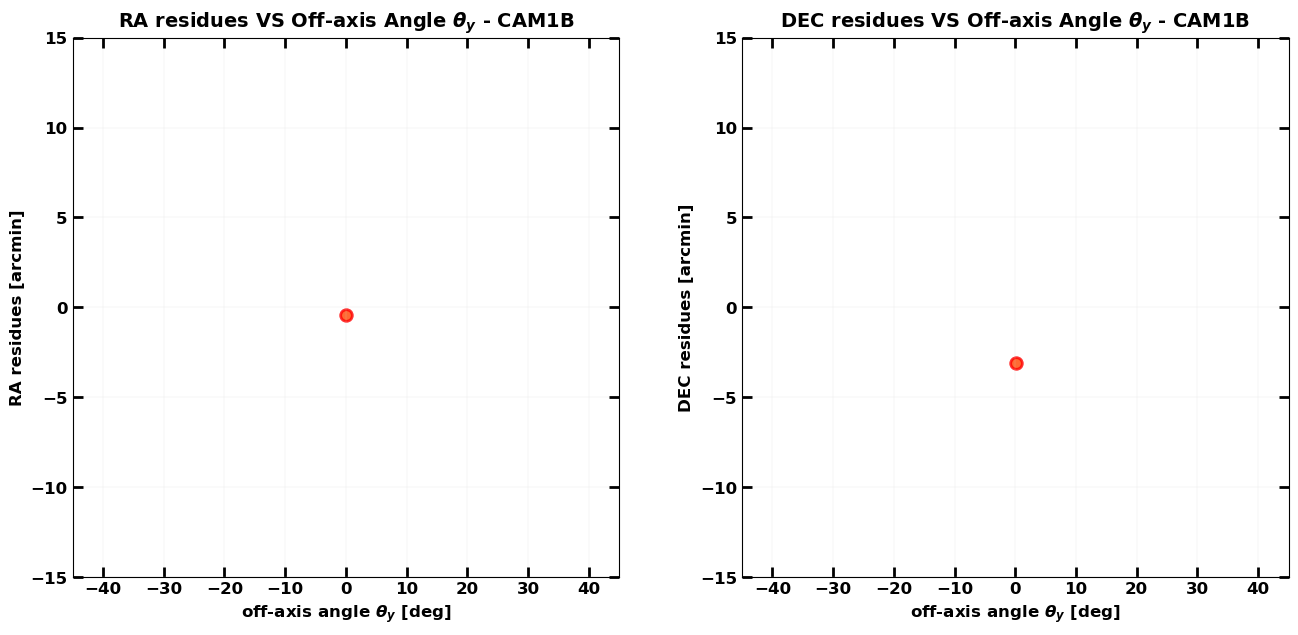

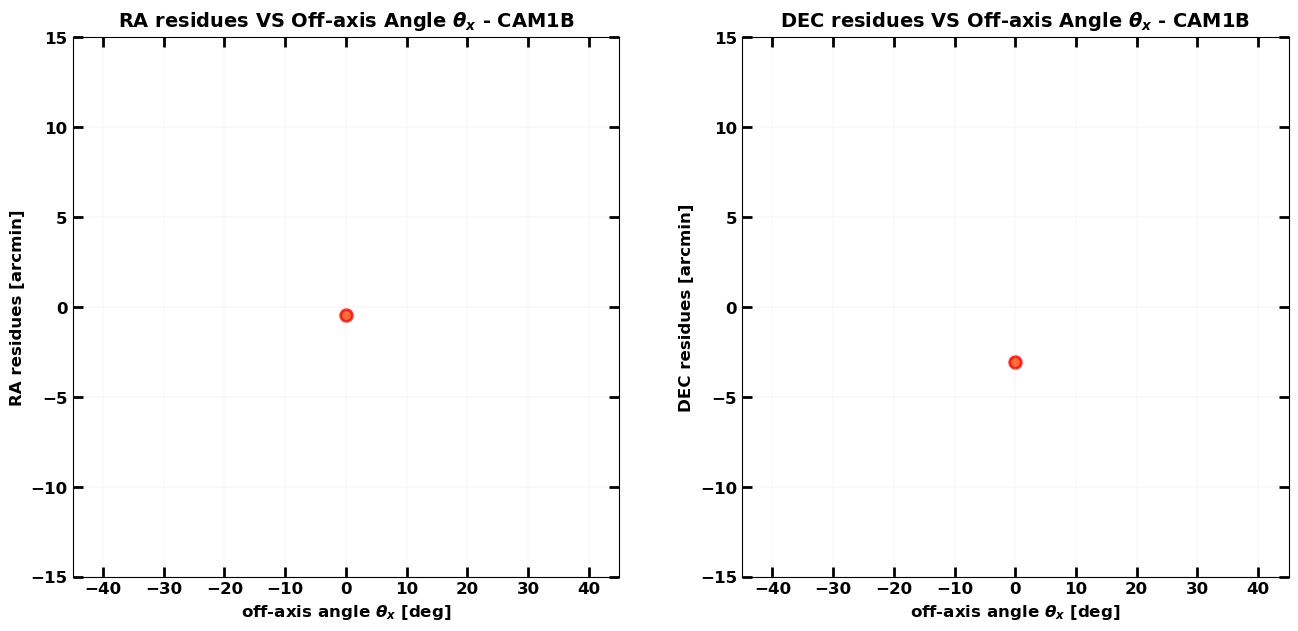

In [8]:
# CAM 1B
ra_res_cam1b = 60*res_df[cam_b]["ra_res"]
thetay_cam1b = database[cam_b]["theta_y"]["data"]

dec_res_cam1b = 60*res_df[cam_b]["dec_res"]
thetax_cam1b = database[cam_b]["theta_x"]["data"]

#thetay_cam1b = np.delete(thetay_cam1b, 13); thetax_cam1b = np.delete(thetax_cam1b, 13)


offsetx=[(-45, 45)]*2
offsety=[(-15, 15)]*2

iros.plot_sequence(
    input_sequence=[ra_res_cam1b, dec_res_cam1b],
    title=[r"RA residues VS Off-axis Angle $\theta_{y}$ - CAM1B", r"DEC residues VS Off-axis Angle $\theta_{y}$ - CAM1B"],
    x=[thetay_cam1b, thetay_cam1b],
    xlabel=[r"off-axis angle $\theta_{y}$" + " [deg]", r"off-axis angle $\theta_{y}$" + " [deg]"],
    ylabel=["RA residues [arcmin]", "DEC residues [arcmin]"],
    style=["scatter"]*2,
    offsetx=offsetx,
    offsety=offsety,
)
iros.plot_sequence(
    input_sequence=[ra_res_cam1b, dec_res_cam1b],
    title=[r"RA residues VS Off-axis Angle $\theta_{x}$ - CAM1B", r"DEC residues VS Off-axis Angle $\theta_{x}$ - CAM1B"],
    x=[thetax_cam1b, thetax_cam1b],
    xlabel=[r"off-axis angle $\theta_{x}$" + " [deg]", r"off-axis angle $\theta_{x}$" + " [deg]"],
    ylabel=["RA residues [arcmin]", "DEC residues [arcmin]"],
    style=["scatter"]*2,
    offsetx=offsetx,
    offsety=offsety,
)

- Scatter plot with IROS sources vs catalog sources off-axis angles $\theta_{y}$, $\theta_{x}$ distribution

In [9]:
from copy import deepcopy
from pandas import DataFrame

from mbloodmoon.io import SimulationDataLoader
from mbloodmoon.mask import CodedMaskCamera
from mbloodmoon.coords import equatorial2shift, shift2theta

from temp_camera import codedmask

def get_catalog_theta(
    data: dict,
    catalogs: tuple[np.recarray],
    sdls: tuple[SimulationDataLoader],
    camera: CodedMaskCamera,
) -> DataFrame:
    """Returns catalog sources respective camera angular coordinates."""
    db = {
        cameraID: deepcopy({
            "theta_x": [],
            "theta_y": [],
        })
        for cameraID in data.keys()
    }

    for sdl, cat, cameraID in zip(
        sdls, catalogs, data.keys(),
    ):
        print(f"# Checking {cameraID.upper()}...")
        for name in data[cameraID]["catalog_name"]["data"]:
            cat_ra = cat.data[cat.data["NAME"] == name]["RA"][0]
            cat_dec = cat.data[cat.data["NAME"] == name]["DEC"][0]
            sx, sy = equatorial2shift(sdl, camera, cat_ra, cat_dec)
            db[cameraID]["theta_x"].append(shift2theta(camera, sx))
            db[cameraID]["theta_y"].append(shift2theta(camera, sy))

    return iros.dict2df(db)


wfm = codedmask(mask_path, 5, 1)
sdlA = bm.simulation(filepaths[cam_a][dataset])
sdlB = bm.simulation(filepaths[cam_b][dataset])
catalog_theta = get_catalog_theta(database, (catalogA, catalogB), (sdlA, sdlB), wfm)

# Checking CAM1A...
# Checking CAM1B...


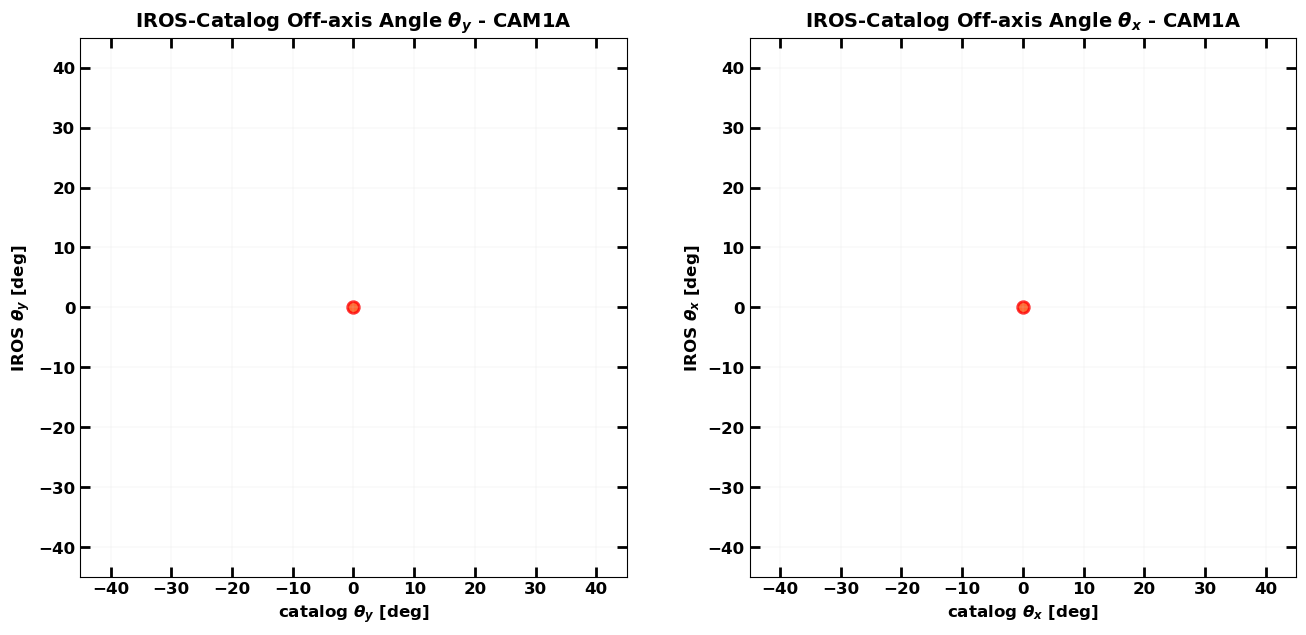

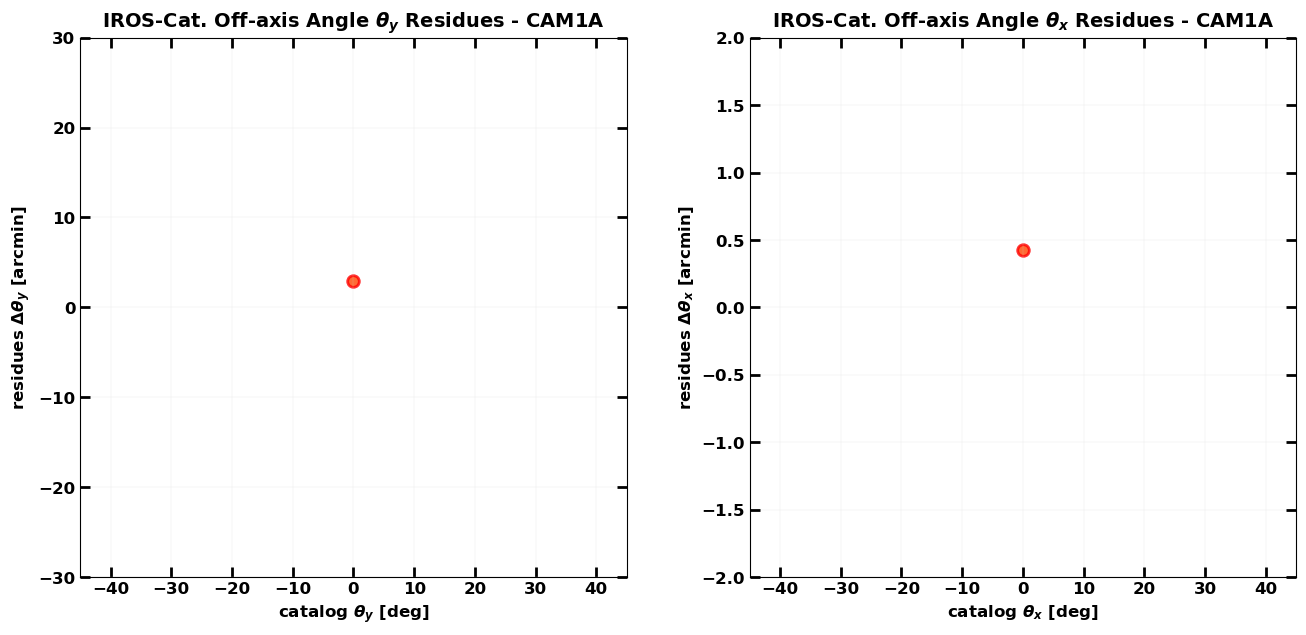

In [10]:
# CAM1A
thetay_cam1a = database[cam_a]["theta_y"]["data"]
thetax_cam1a = database[cam_a]["theta_x"]["data"]

thetay_catalog_cam1a = catalog_theta[cam_a]["theta_y"]
thetax_catalog_cam1a = catalog_theta[cam_a]["theta_x"]

#thetay_cam1a = np.delete(thetay_cam1a, 13); thetax_cam1a = np.delete(thetax_cam1a, 13)

iros.plot_sequence(
    input_sequence=[thetay_cam1a, thetax_cam1a],
    title=[r"IROS-Catalog Off-axis Angle $\theta_{y}$ - CAM1A", r"IROS-Catalog Off-axis Angle $\theta_{x}$ - CAM1A"],
    x=[thetay_catalog_cam1a, thetax_catalog_cam1a],
    xlabel=[r"catalog $\theta_{y}$" + " [deg]", r"catalog $\theta_{x}$" + " [deg]"],
    ylabel=[r"IROS $\theta_{y}$" + " [deg]", r"IROS $\theta_{x}$" + " [deg]"],
    style=["scatter"]*2,
    offsetx=[(-45, 45)] * 2,
    offsety=[(-45, 45)] * 2,
)

iros.plot_sequence(
    input_sequence=[60 * (thetay_cam1a - thetay_catalog_cam1a), 60 * (thetax_cam1a - thetax_catalog_cam1a)],
    title=[r"IROS-Cat. Off-axis Angle $\theta_{y}$ Residues - CAM1A", r"IROS-Cat. Off-axis Angle $\theta_{x}$ Residues - CAM1A"],
    x=[thetay_catalog_cam1a, thetax_catalog_cam1a],
    xlabel=[r"catalog $\theta_{y}$" + " [deg]", r"catalog $\theta_{x}$" + " [deg]"],
    ylabel=[r"residues $\Delta\theta_{y}$" + " [arcmin]", r"residues $\Delta\theta_{x}$" + " [arcmin]"],
    style=["scatter"]*2,
    offsetx=offsetx,
    offsety=[(-30, 30), (-2, 2)],
)

# iros.plot_sequence(
#     input_sequence=[thetay_cam1a, thetay_cam1a],
#     title=[r"IROS-Catalog Off-axis Angle $\theta_{y}$ - CAM1A"] * 2,
#     x=[thetay_catalog_cam1a, thetax_catalog_cam1a],
#     xlabel=[r"catalog $\theta_{y}$" + " [deg]", r"catalog $\theta_{x}$" + " [deg]"],
#     ylabel=[r"IROS $\theta_{y}$" + " [deg]"] * 2,
#     style=["scatter"]*2,
#     offsetx=offsetx,
#     offsety=offsety,
# )
# 
# iros.plot_sequence(
#     input_sequence=[thetax_cam1a, thetax_cam1a],
#     title=[r"IROS-Catalog Off-axis Angle $\theta_{x}$ - CAM1A"] * 2,
#     x=[thetay_catalog_cam1a, thetax_catalog_cam1a],
#     xlabel=[r"catalog $\theta_{y}$" + " [deg]", r"catalog $\theta_{x}$" + " [deg]"],
#     ylabel=[r"IROS $\theta_{x}$" + " [deg]"] * 2,
#     style=["scatter"]*2,
#     offsetx=offsetx,
#     offsety=offsety,
# )

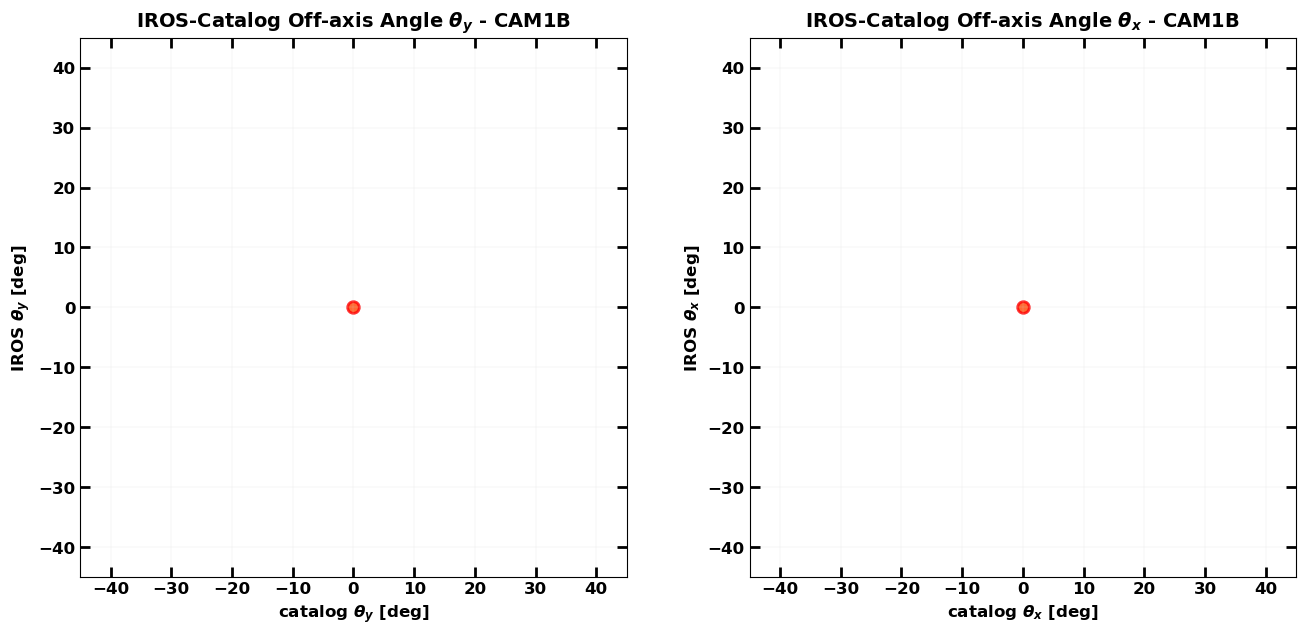

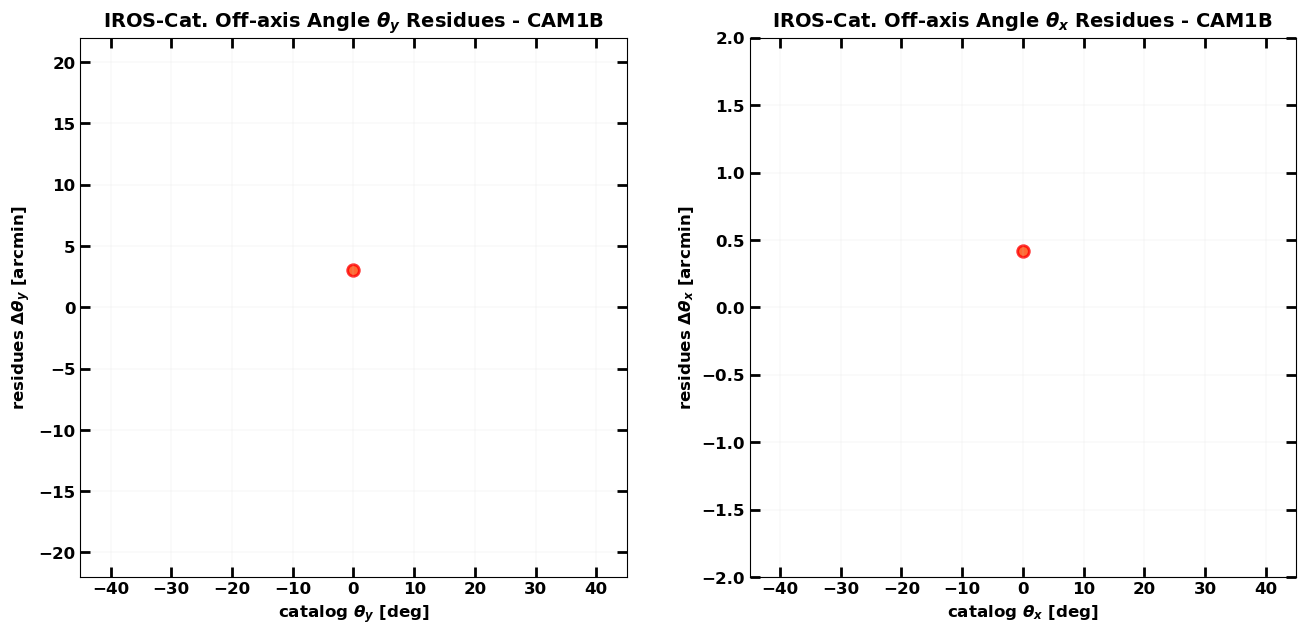

In [11]:
# CAM1B
thetay_cam1b = database[cam_b]["theta_y"]["data"]
thetax_cam1b = database[cam_b]["theta_x"]["data"]

thetay_catalog_cam1b = catalog_theta[cam_b]["theta_y"]
thetax_catalog_cam1b = catalog_theta[cam_b]["theta_x"]

#thetay_cam1b = np.delete(thetay_cam1b, 13); thetax_cam1b = np.delete(thetax_cam1b, 13)

iros.plot_sequence(
    input_sequence=[thetay_cam1b, thetax_cam1b],
    title=[r"IROS-Catalog Off-axis Angle $\theta_{y}$ - CAM1B", r"IROS-Catalog Off-axis Angle $\theta_{x}$ - CAM1B"],
    x=[thetay_catalog_cam1b, thetax_catalog_cam1b],
    xlabel=[r"catalog $\theta_{y}$" + " [deg]", r"catalog $\theta_{x}$" + " [deg]"],
    ylabel=[r"IROS $\theta_{y}$" + " [deg]", r"IROS $\theta_{x}$" + " [deg]"],
    style=["scatter"]*2,
    offsetx=[(-45, 45)] * 2,
    offsety=[(-45, 45)] * 2,
)

iros.plot_sequence(
    input_sequence=[60 * (thetay_cam1b - thetay_catalog_cam1b), 60 * (thetax_cam1b - thetax_catalog_cam1b)],
    title=[r"IROS-Cat. Off-axis Angle $\theta_{y}$ Residues - CAM1B", r"IROS-Cat. Off-axis Angle $\theta_{x}$ Residues - CAM1B"],
    x=[thetay_catalog_cam1b, thetax_catalog_cam1b],
    xlabel=[r"catalog $\theta_{y}$" + " [deg]", r"catalog $\theta_{x}$" + " [deg]"],
    ylabel=[r"residues $\Delta\theta_{y}$" + " [arcmin]", r"residues $\Delta\theta_{x}$" + " [arcmin]"],
    style=["scatter"]*2,
    offsetx=offsetx,
    offsety=[(-22, 22), (-2, 2)],
)

# iros.plot_sequence(
#     input_sequence=[thetay_cam1b, thetay_cam1b],
#     title=[r"IROS-Catalog Off-axis Angle $\theta_{y}$ - CAM1B"] * 2,
#     x=[thetay_catalog_cam1b, thetax_catalog_cam1b],
#     xlabel=[r"catalog $\theta_{y}$" + " [deg]", r"catalog $\theta_{x}$" + " [deg]"],
#     ylabel=[r"IROS $\theta_{y}$" + " [deg]"] * 2,
#     style=["scatter"]*2,
#     offsetx=offsetx,
#     offsety=offsety,
# )
# 
# iros.plot_sequence(
#     input_sequence=[thetax_cam1b, thetax_cam1b],
#     title=[r"IROS-Catalog Off-axis Angle $\theta_{x}$ - CAM1B"] * 2,
#     x=[thetay_catalog_cam1b, thetax_catalog_cam1b],
#     xlabel=[r"catalog $\theta_{y}$" + " [deg]", r"catalog $\theta_{x}$" + " [deg]"],
#     ylabel=[r"IROS $\theta_{x}$" + " [deg]"] * 2,
#     style=["scatter"]*2,
#     offsetx=offsetx,
#     offsety=offsety,
# )

In [ ]:
print(
    60 * (thetax_cam1a - thetax_catalog_cam1a),
    60 * (thetax_cam1b - thetax_catalog_cam1b),
    database[cam_a]["shift_x"]["data"],
    database[cam_a]["shift_y"]["data"],
    wfm.bins_sky.x[len(wfm.bins_sky.x) // 2 - 1],
    wfm.bins_sky.y[len(wfm.bins_sky.y) // 2 - 1],
    len(wfm.bins_sky.x) - 1,
)

print(wfm.bins_sky.x[0], wfm.bins_sky.x[-1])

print(
    f"Shift sky (-1): {wfm.bins_sky.x[len(wfm.bins_sky.x) // 2 - 1]}\n",
    f"Shift sky: {wfm.bins_sky.x[len(wfm.bins_sky.x) // 2]}",
)

print(
    f"Shift mask: {wfm.bins_mask.x[len(wfm.bins_mask.x) // 2 - 1]}\n",
    f"Shift mask: {wfm.bins_mask.x[len(wfm.bins_mask.x) // 2]}\n",
    f"Shift detector: {wfm.bins_detector.x[len(wfm.bins_detector.x) // 2]}",
)

print(
    wfm.mask_shape,
    wfm.detector_shape,
    wfm.sky_shape,
)

- Bar plot with sources slices

In [ ]:
res_sky_camA, _ = iros.load_sky(save_path + f"skyRES_IROS_CAM1A_TEST_{N_TEST}.fits")
res_sky_camB, _ = iros.load_sky(save_path + f"skyRES_IROS_CAM1B_TEST_{N_TEST}.fits")

sky_camA, _ = iros.load_sky(save_path + f"OUTsky_IROS_CAM1A_TEST_{N_TEST}.fits")
sky_camB, _ = iros.load_sky(save_path + f"OUTsky_IROS_CAM1B_TEST_{N_TEST}.fits")

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


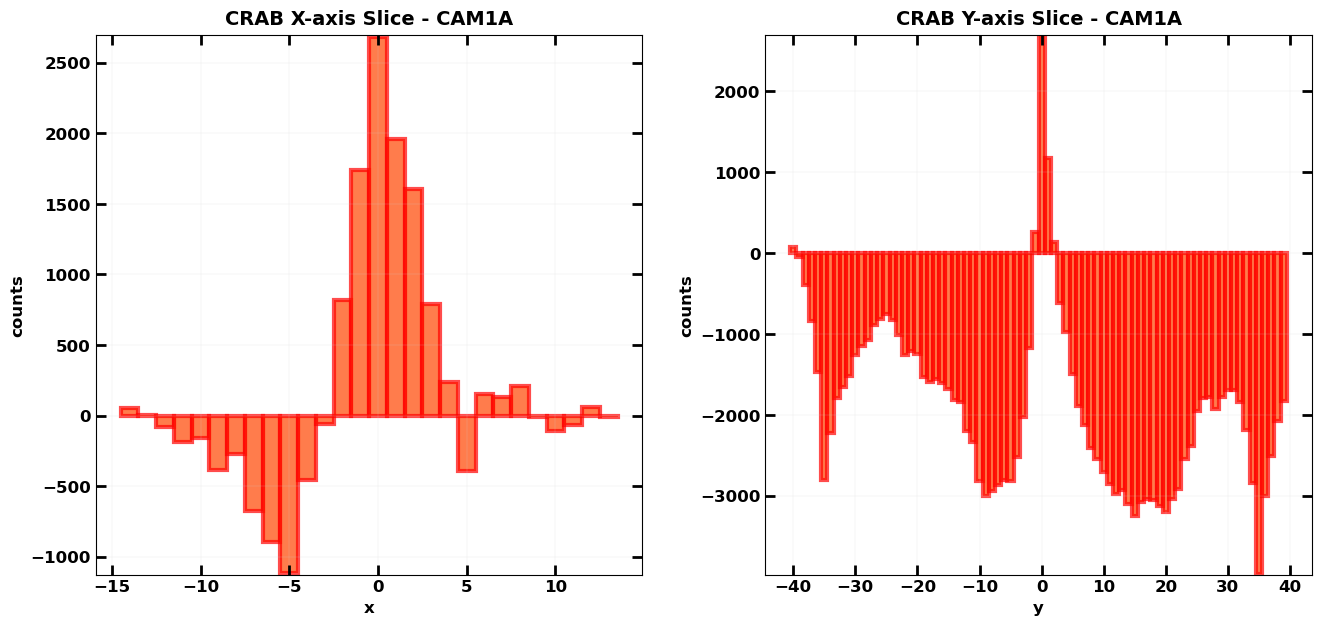

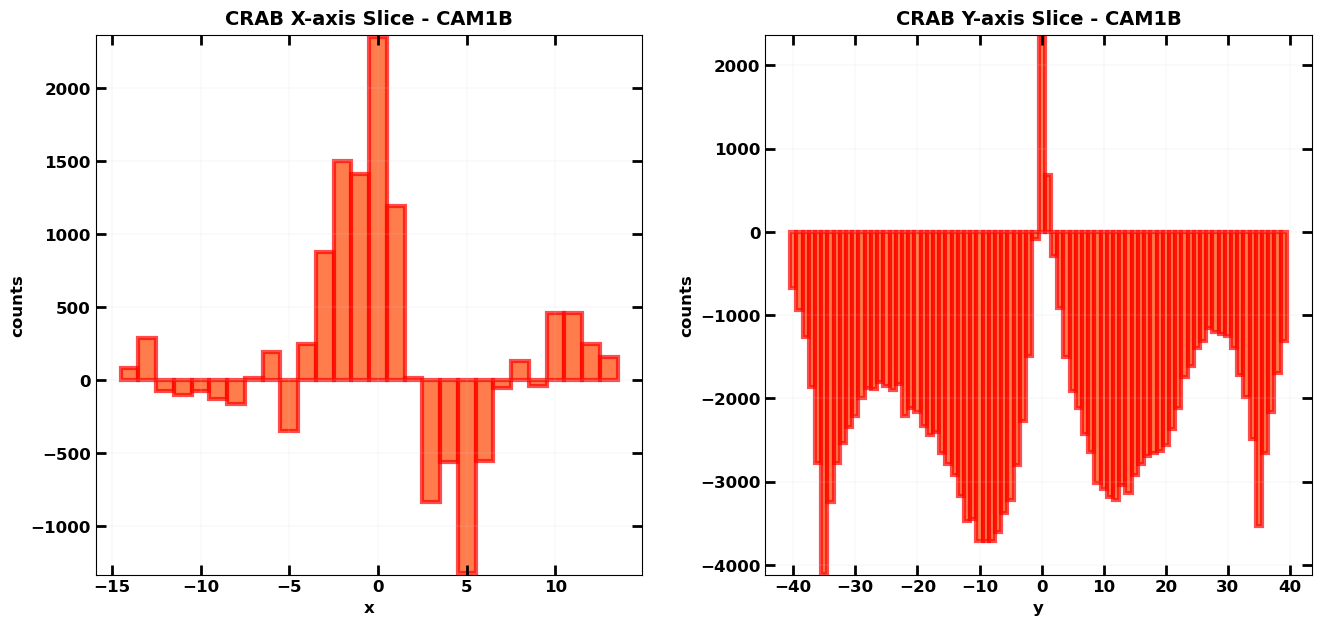

In [ ]:
# CAM1A
_to = 3

for source, y, x in zip(
    database[cam_a]["catalog_name"]["data"][:_to],
    database[cam_a]["y"]["data"][:_to],
    database[cam_a]["x"]["data"][:_to],
):
    iros.enhance_slices(
        sky=res_sky_camA,
        pos=(y, x),
        crp=(40, 14),
        source=source,
        cameraID=cam_a,
    )

In [ ]:
# CAM1B
_to = 3

for source, y, x in zip(
    database[cam_b]["catalog_name"]["data"][:_to],
    database[cam_b]["y"]["data"][:_to],
    database[cam_b]["x"]["data"][:_to],
):
    iros.enhance_slices(
        sky=res_sky_camB,
        pos=(y, x),
        crp=(40, 14),
        source=source,
        cameraID=cam_b,
    )

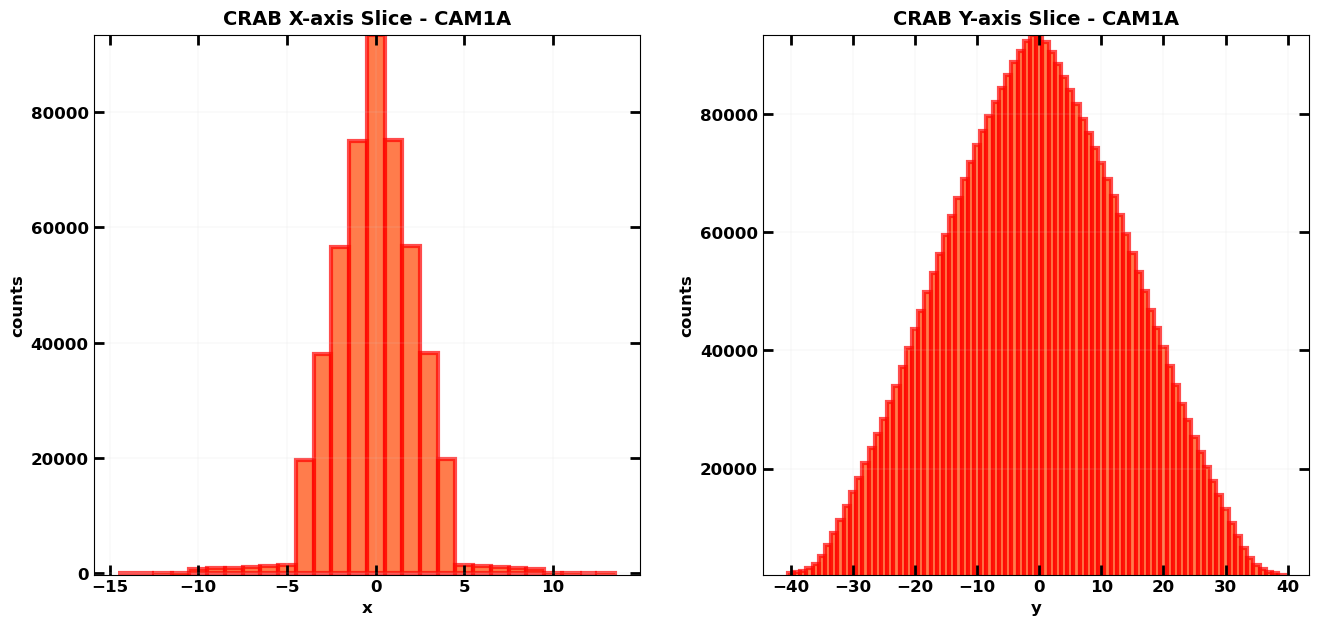

In [16]:
# CAM1A
_to = 3

for source, y, x in zip(
    database[cam_a]["catalog_name"]["data"][:_to],
    database[cam_a]["y"]["data"][:_to],
    database[cam_a]["x"]["data"][:_to],
):
    iros.enhance_slices(
        sky=sky_camA,
        pos=(y, x),
        crp=(40, 14),
        source=source,
        cameraID=cam_a,
    )

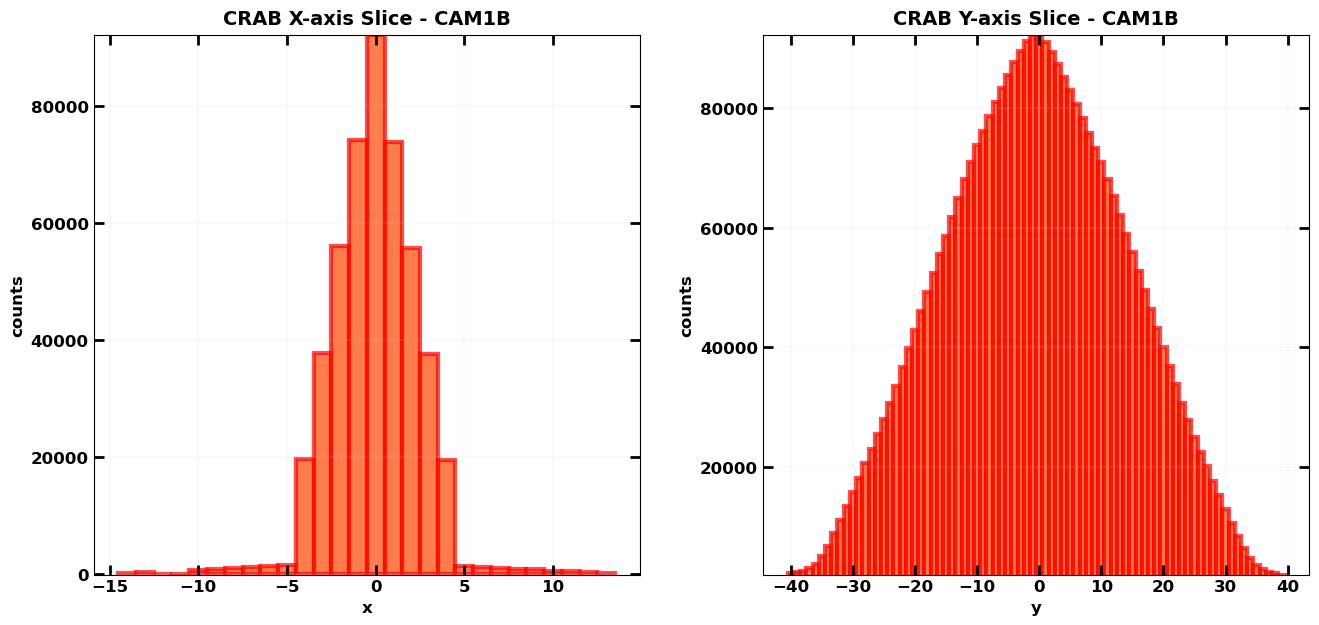

In [17]:
# CAM1B
_to = 3

for source, y, x in zip(
    database[cam_b]["catalog_name"]["data"][:_to],
    database[cam_b]["y"]["data"][:_to],
    database[cam_b]["x"]["data"][:_to],
):
    iros.enhance_slices(
        sky=sky_camB,
        pos=(y, x),
        crp=(40, 14),
        source=source,
        cameraID=cam_b,
    )

- Histogram with RA/DEC residues between IROS and catalog sources

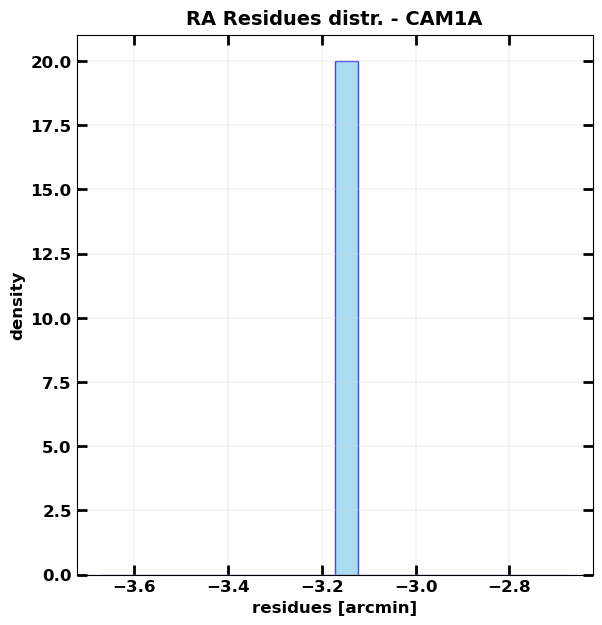

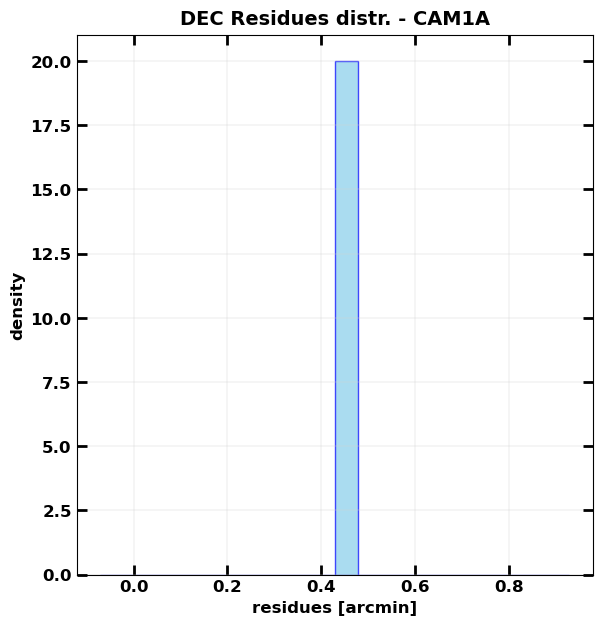

In [18]:
iros.plot_distr(
    arr=ra_res_cam1a,
    title=f"RA Residues distr. - {cam_a.upper()}",
    bins=20,
    xlabel="residues [arcmin]",
)
iros.plot_distr(
    arr=dec_res_cam1a,
    title=f"DEC Residues distr. - {cam_a.upper()}",
    bins=20,
    xlabel="residues [arcmin]",
)

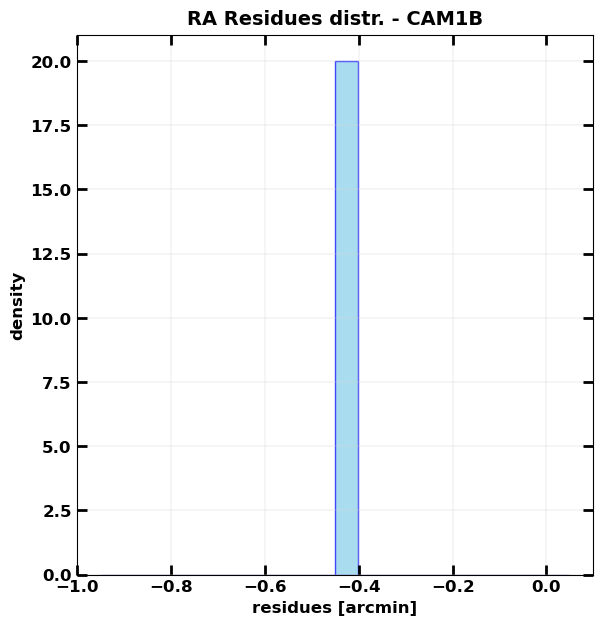

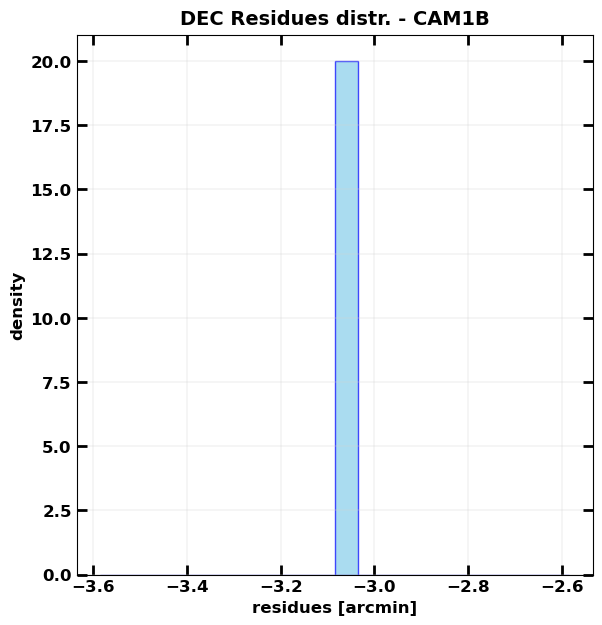

In [19]:
iros.plot_distr(
    arr=ra_res_cam1b,
    title=f"RA Residues distr. - {cam_b.upper()}",
    bins=20,
    xlabel="residues [arcmin]",
)
iros.plot_distr(
    arr=dec_res_cam1b,
    title=f"DEC Residues distr. - {cam_b.upper()}",
    bins=20,
    xlabel="residues [arcmin]",
)

- Histogram with angular separation between IROS and catalog sources

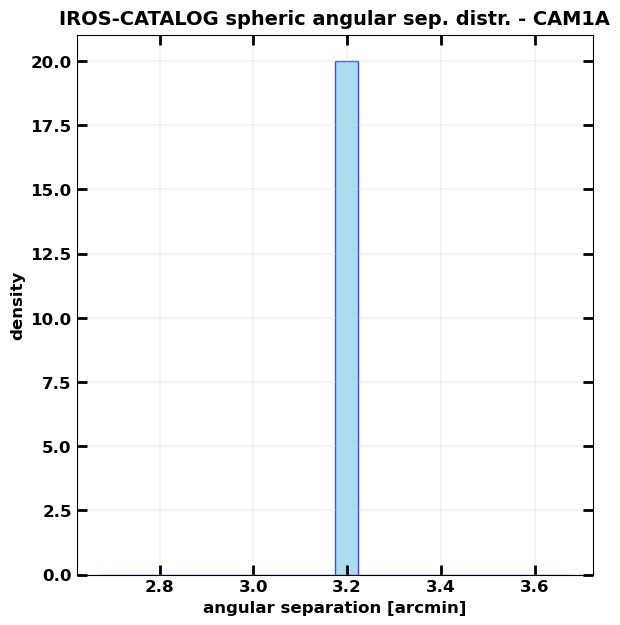

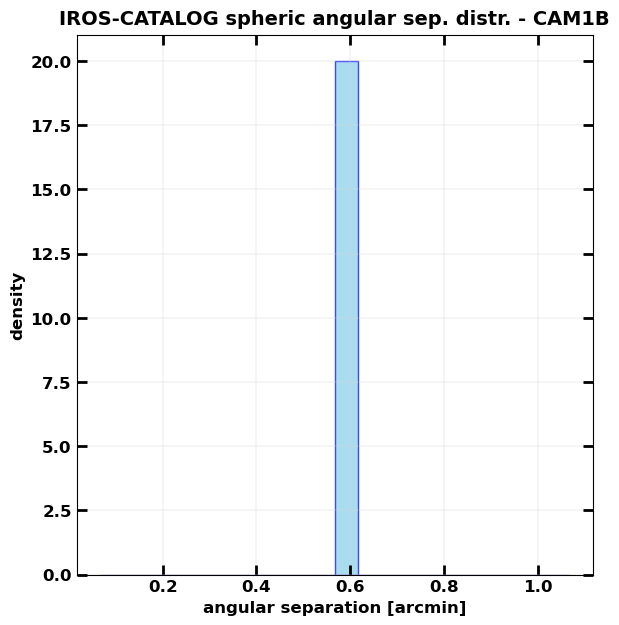

In [20]:
import astropy.units as u
from astropy.coordinates import Angle
from astropy.coordinates.angles.utils import angular_separation

ang_sep_cam1a = []
ang_sep_cam1b = []


# careful here, `angular_separation` output is in [rad]
for cam, cat, ang_sep in zip(
    (cam_a, cam_b),
    (catalogA, catalogB),
    (ang_sep_cam1a, ang_sep_cam1b),
):
    for iros_dec, iros_ra, name in zip(
        database[cam]["dec"]["data"],
        database[cam]["ra"]["data"],
        database[cam]["catalog_name"]["data"],        
    ):
        cat_dec = cat.data[cat.data["NAME"] == name]["DEC"][0]
        cat_ra = cat.data[cat.data["NAME"] == name]["RA"][0]
        ang_sep.append(
            np.rad2deg(
                angular_separation(
                    Angle(iros_dec, unit=u.deg), Angle(iros_ra, unit=u.deg),
                    Angle(cat_dec, unit=u.deg), Angle(cat_ra, unit=u.deg),
                ).value,
            ),
        )


iros.plot_distr(
    arr=60 * np.array(ang_sep_cam1a),
    title=f"IROS-CATALOG spheric angular sep. distr. - {cam_a.upper()}",
    bins=20,
    xlabel="angular separation [arcmin]"
)

iros.plot_distr(
    arr=60 * np.array(ang_sep_cam1b),
    title=f"IROS-CATALOG spheric angular sep. distr. - {cam_b.upper()}",
    bins=20,
    xlabel="angular separation [arcmin]"
)

- Counts distribution of the IROS skies residues

In [21]:
skyres_camA, snrres_camA = iros.load_sky(save_path + f"skyRES_IROS_CAM1A_TEST_{N_TEST}.fits")
skyres_camB, snrres_camB = iros.load_sky(save_path + f"skyRES_IROS_CAM1B_TEST_{N_TEST}.fits")

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


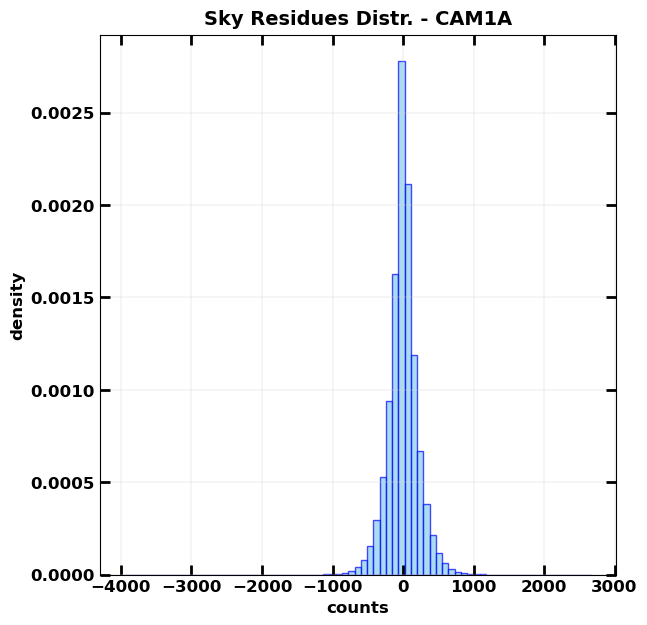

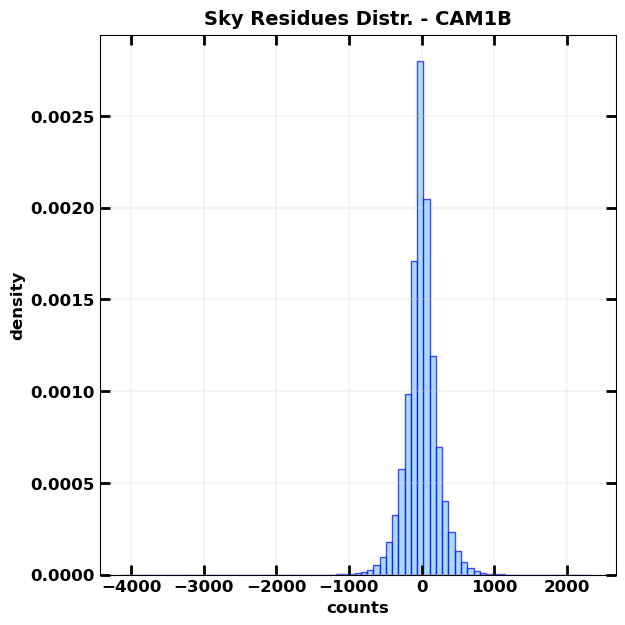

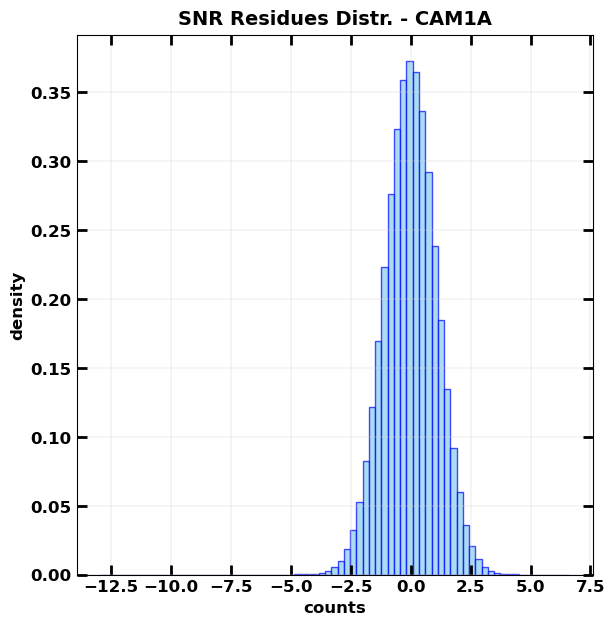

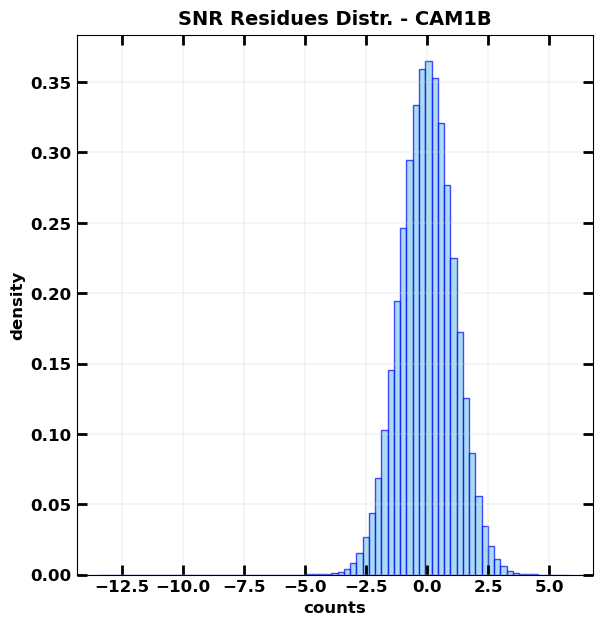

In [22]:
iros.plot_distr(
    arr=skyres_camA,
    title=f"Sky Residues Distr. - {cam_a.upper()}",
    bins=75,
    xlabel="counts",
    #cut=(-1e4, 1e4),
)

iros.plot_distr(
    arr=skyres_camB,
    title=f"Sky Residues Distr. - {cam_b.upper()}",
    bins=75,
    xlabel="counts",
)

iros.plot_distr(
    arr=snrres_camA,
    title=f"SNR Residues Distr. - {cam_a.upper()}",
    bins=75,
    xlabel="counts",
)

iros.plot_distr(
    arr=snrres_camB,
    title=f"SNR Residues Distr. - {cam_b.upper()}",
    bins=75,
    xlabel="counts",
)